In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# 1. Copy file từ Drive sang bộ nhớ tạm của Colab
!cp /content/drive/MyDrive/wood.zip /content/

# 2. Giải nén vào thư mục datasets
!unzip -q /content/wood.zip -d /content/datasets/

In [3]:
import os
import random
import shutil
from tqdm import tqdm

# --- CẤU HÌNH ĐƯỜNG DẪN ---
root_dir = '/content/datasets' # Thư mục gốc chứa train, test, valid cũ
output_dir = '/content/refined_dataset'
split_ratio = [0.8, 0.1, 0.1] # 80% Train, 10% Val, 10% Test

# Tạo cấu trúc thư mục mới
for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(output_dir, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, split, 'labels'), exist_ok=True)

# 1. Thu thập tất cả cặp (Ảnh, Nhãn) từ các folder cũ
all_data = []
old_splits = ['train', 'test', 'valid'] # Liệt kê các folder cũ bạn đang có

for s in old_splits:
    img_path = os.path.join(root_dir, s, 'images')
    if not os.path.exists(img_path): continue

    for filename in os.listdir(img_path):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            base_name = os.path.splitext(filename)[0]
            label_name = base_name + '.txt'
            label_path = os.path.join(root_dir, s, 'labels', label_name)

            # Chỉ lấy nếu có cả file ảnh và file nhãn
            if os.path.exists(label_path):
                all_data.append((os.path.join(img_path, filename), label_path))

print(f"Tổng cộng tìm thấy: {len(all_data)} cặp dữ liệu.")

# 2. Trộn ngẫu nhiên
random.seed(42) # Giữ kết quả cố định mỗi lần chạy
random.shuffle(all_data)

# 3. Tính toán điểm chia
n_total = len(all_data)
n_train = int(n_total * split_ratio[0])
n_val = int(n_total * split_ratio[1])

train_files = all_data[:n_train]
val_files = all_data[n_train:n_train + n_val]
test_files = all_data[n_train + n_val:]

# 4. Hàm copy file vào folder mới
def copy_files(file_list, split_name):
    for img_src, lab_src in tqdm(file_list, desc=f"Copying {split_name}"):
        img_name = os.path.basename(img_src)
        lab_name = os.path.basename(lab_src)

        shutil.copy(img_src, os.path.join(output_dir, split_name, 'images', img_name))
        shutil.copy(lab_src, os.path.join(output_dir, split_name, 'labels', lab_name))

copy_files(train_files, 'train')
copy_files(val_files, 'valid')
copy_files(test_files, 'test')

print("--- HOÀN THÀNH CHIA DATASET ---")
print(f"Train: {len(train_files)} | Valid: {len(val_files)} | Test: {len(test_files)}")

Tổng cộng tìm thấy: 10783 cặp dữ liệu.


Copying test: 100%|██████████| 1079/1079 [00:00<00:00, 1144.08it/s]

--- HOÀN THÀNH CHIA DATASET ---
Train: 8626 | Valid: 1078 | Test: 1079


In [4]:
yaml_content = f"""
train: {output_dir}/train/images
val: {output_dir}/valid/images
test: {output_dir}/test/images

nc: 4
names: ['Crack', 'Dead_Knot', 'Live_Knot', 'Marrow']
"""

with open(os.path.join(output_dir, 'data.yaml'), 'w') as f:
    f.write(yaml_content)

In [5]:
import os

def check_dataset_health(dataset_path):
    splits = ['train', 'valid', 'test']
    for split in splits:
        img_dir = os.path.join(dataset_path, split, 'images')
        lab_dir = os.path.join(dataset_path, split, 'labels')

        imgs = os.listdir(img_dir)
        count_empty = 0
        count_missing = 0

        for img in imgs:
            lab_file = os.path.splitext(img)[0] + '.txt'
            lab_path = os.path.join(lab_dir, lab_file)

            if not os.path.exists(lab_path):
                count_missing += 1
                continue

            if os.path.getsize(lab_path) == 0:
                count_empty += 1

        print(f"--- Kết quả tập {split.upper()} ---")
        print(f"Tổng số ảnh: {len(imgs)}")
        print(f"Thiếu file nhãn: {count_missing}")
        print(f"File nhãn trống (Background): {count_empty}")
        print("-" * 30)

# Chạy kiểm tra cho folder mới chia
check_dataset_health('/content/refined_dataset')

--- Kết quả tập TRAIN ---
Tổng số ảnh: 8626
Thiếu file nhãn: 0
File nhãn trống (Background): 129
------------------------------
--- Kết quả tập VALID ---
Tổng số ảnh: 1078
Thiếu file nhãn: 0
File nhãn trống (Background): 20
------------------------------
--- Kết quả tập TEST ---
Tổng số ảnh: 1079
Thiếu file nhãn: 0
File nhãn trống (Background): 23
------------------------------


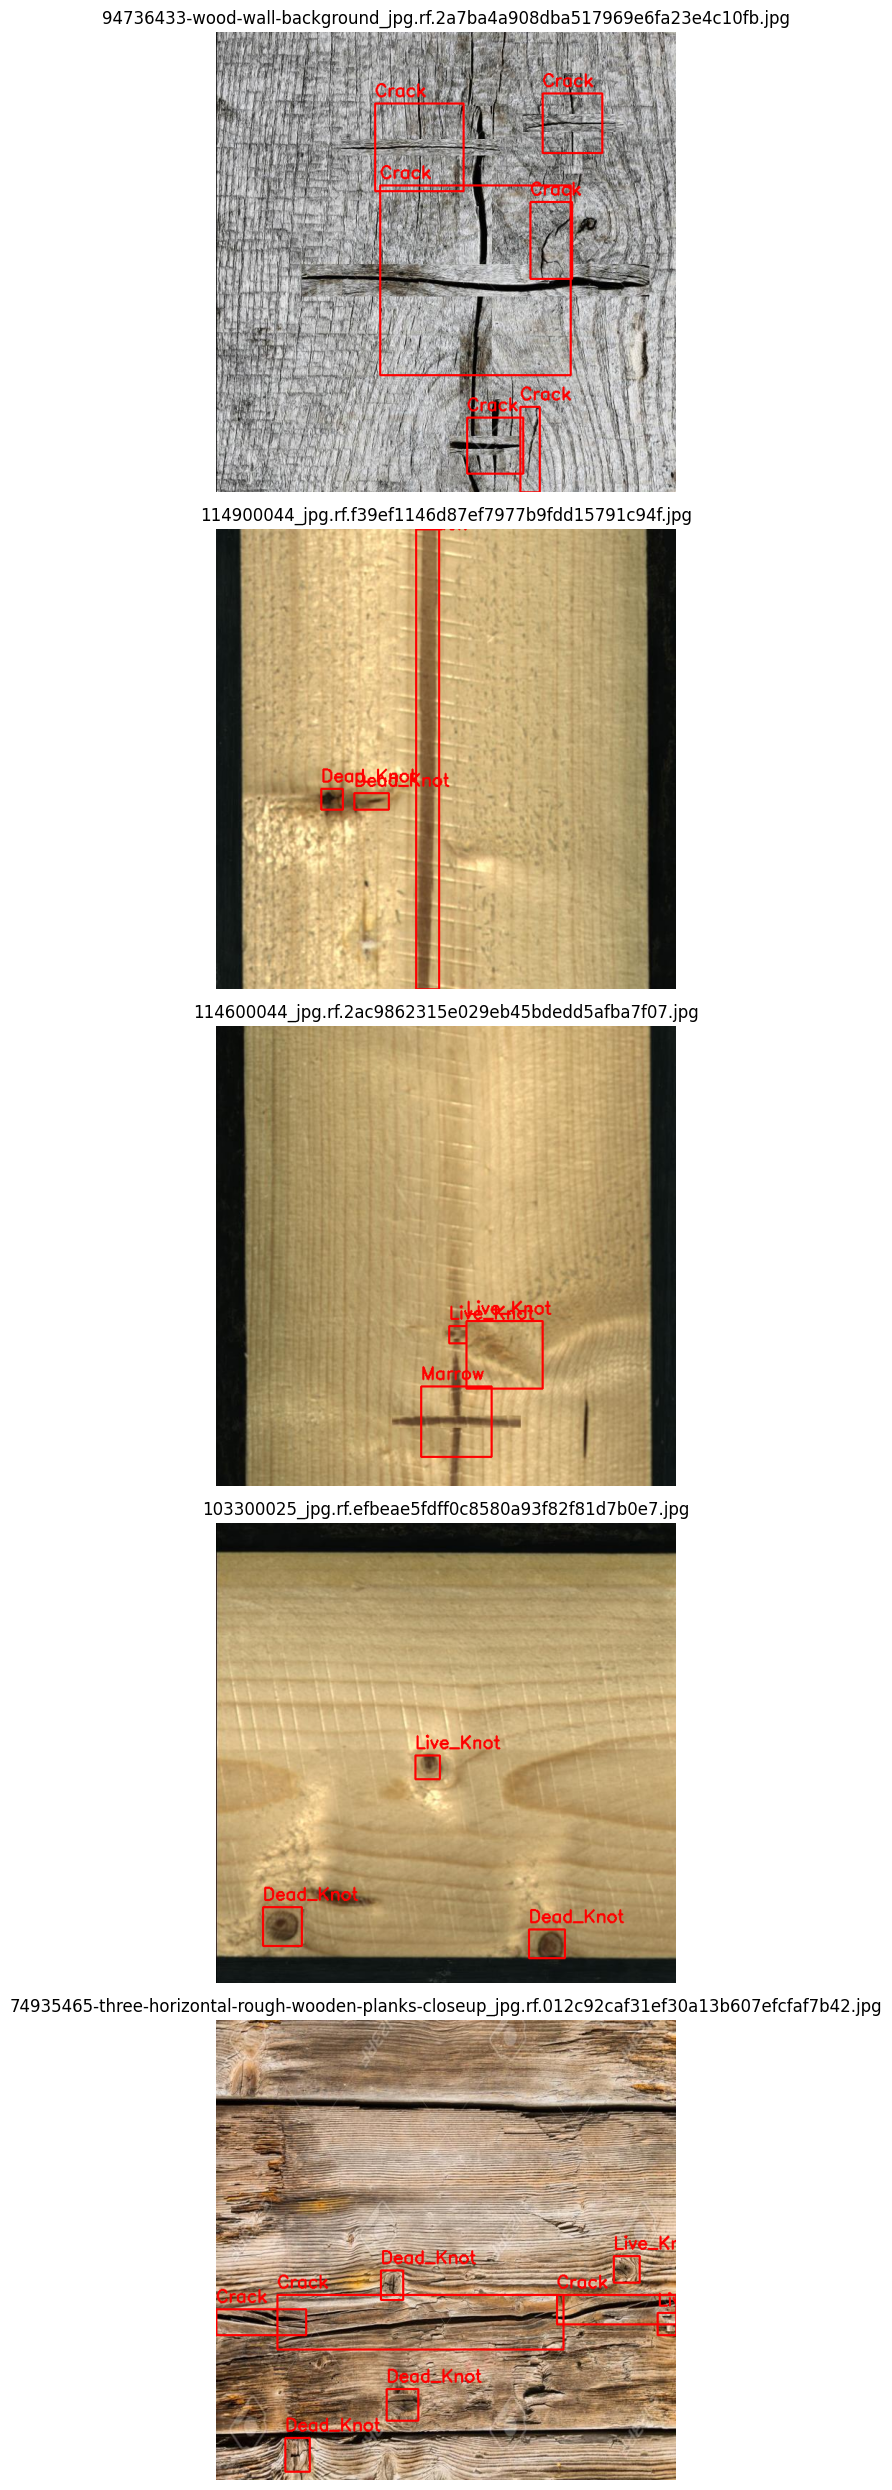

In [6]:
import cv2
import random
import matplotlib.pyplot as plt
import glob
import os

# Define paths to the refined training dataset
img_dir = "/content/refined_dataset/train/images"
label_dir = "/content/refined_dataset/train/labels"

# Fetch all image paths
imgs = []
for ext in ["*.jpg", "*.jpeg", "*.png"]:
    imgs.extend(glob.glob(os.path.join(img_dir, ext)))

# Shuffle to ensure random sampling
random.shuffle(imgs)

# Define class names corresponding to the data.yaml
class_names = [
    "Crack",
    "Dead_Knot",
    "Live_Knot",
    "Marrow"
]

num_images = 5  # Number of samples to visualize
fig, axes = plt.subplots(num_images, 1, figsize=(10, num_images * 5))

if num_images == 1:
    axes = [axes]

for ax, r in zip(axes, imgs[:num_images]):
    imgname = os.path.basename(r)
    lab = os.path.join(label_dir, imgname.rsplit(".", 1)[0] + ".txt")

    img = cv2.imread(r)
    if img is None:
        ax.set_title("Error: " + imgname, color="red")
        ax.axis("off")
        continue

    # Convert BGR to RGB for correct Matplotlib rendering
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if os.path.exists(lab):
        with open(lab) as f:
            for l in f:
                parts = l.strip().split()
                if len(parts) != 5:
                    continue

                cls, cx, cy, nw, nh = map(float, parts)

                # Denormalize coordinates to absolute pixel values
                abs_cx, abs_cy = cx * w, cy * h
                ww, hh = nw * w, nh * h

                x1 = int(abs_cx - ww / 2)
                y1 = int(abs_cy - hh / 2)
                x2 = int(abs_cx + ww / 2)
                y2 = int(abs_cy + hh / 2)

                label_text = class_names[int(cls)] if int(cls) < len(class_names) else str(int(cls))

                # Draw bounding box and label
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                cv2.putText(img, label_text, (x1, max(y1 - 10, 0)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

    ax.imshow(img)
    ax.set_title(imgname, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
import os
import shutil
from google.colab import drive

# 1. Kết nối (Mount) với Google Drive của bạn
# Khi chạy dòng này, Colab sẽ hiện ra một popup yêu cầu bạn chọn tài khoản Google và cho phép truy cập.
print("Đang kết nối với Google Drive...")
drive.mount('/content/drive')

# 2. Cấu hình đường dẫn
source_dir = '/content/refined_dataset'

# Thư mục đích trên Google Drive (bạn có thể đổi tên thư mục backup tùy ý)
# Mình đặt tên là 'Wood_Defect_Backup' để bạn dễ tìm
dest_dir = '/content/drive/MyDrive/Wood_Defect_Backup/refined_dataset_original'

# 3. Thực hiện copy
print(f"Đang tiến hành sao lưu từ: {source_dir}")
print(f"Sang đích đến: {dest_dir} ...")

# Kiểm tra xem thư mục đích đã tồn tại chưa để tránh lỗi ghi đè
if os.path.exists(dest_dir):
    print(f"⚠️ Cảnh báo: Thư mục {dest_dir} đã tồn tại!")
    print("Vui lòng xóa thư mục cũ trên Drive hoặc đổi tên biến 'dest_dir' rồi chạy lại.")
else:
    try:
        # Lệnh copy toàn bộ thư mục và nội dung bên trong
        shutil.copytree(source_dir, dest_dir)
        print("✅ SAO LƯU THÀNH CÔNG! Dữ liệu gốc của bạn đã được an toàn trên Google Drive.")
    except Exception as e:
        print(f"❌ Có lỗi xảy ra trong quá trình copy: {e}")

Đang kết nối với Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đang tiến hành sao lưu từ: /content/refined_dataset
Sang đích đến: /content/drive/MyDrive/Wood_Defect_Backup/refined_dataset_original ...
✅ SAO LƯU THÀNH CÔNG! Dữ liệu gốc của bạn đã được an toàn trên Google Drive.


In [11]:
import albumentations as A
import cv2
import os
from tqdm import tqdm

# --- 1. CẤU HÌNH ĐƯỜNG DẪN ---
# Trỏ vào đúng thư mục Train của bạn
train_img_dir = '/content/refined_dataset/train/images'
train_label_dir = '/content/refined_dataset/train/labels'

# --- 2. ĐỊNH NGHĨA PIPELINE AUGMENTATION ---
# Các thông số này được tối ưu để không làm mất đi đặc trưng của bề mặt gỗ
transform = A.Compose([
    A.HorizontalFlip(p=0.5), # Lật ngang (50% xác suất)
    A.VerticalFlip(p=0.5),   # Lật dọc (50% xác suất)
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4), # Đổi sáng/tối
    A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=0.3), # Cân bằng sáng cục bộ
    A.GaussianBlur(blur_limit=(3, 5), p=0.2), # Làm mờ nhẹ mô phỏng bụi hoặc camera mất nét
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.2))

# --- 3. HÀM XỬ LÝ CHÍNH ---
def augment_dataset():
    # Lấy danh sách tất cả file ảnh gốc (bỏ qua các file _aug nếu đã chạy trước đó)
    img_files = [f for f in os.listdir(train_img_dir) if f.endswith(('.jpg', '.png', '.jpeg')) and '_aug' not in f]

    print(f"🚀 Bắt đầu Augment cho {len(img_files)} ảnh trong tập Train...")

    success_count = 0
    error_count = 0

    for img_name in tqdm(img_files, desc="Đang xử lý"):
        base_name = os.path.splitext(img_name)[0]
        ext = os.path.splitext(img_name)[1]

        img_path = os.path.join(train_img_dir, img_name)
        label_path = os.path.join(train_label_dir, base_name + '.txt')

        # Đường dẫn lưu file mới
        new_img_path = os.path.join(train_img_dir, base_name + '_aug' + ext)
        new_label_path = os.path.join(train_label_dir, base_name + '_aug.txt')

        # Nếu không có file nhãn đi kèm, bỏ qua (để tránh lỗi)
        if not os.path.exists(label_path):
            continue

        # Đọc ảnh
        image = cv2.imread(img_path)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Đọc tọa độ Bbox
        bboxes = []
        class_labels = []
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id = int(parts[0])
                    bbox = [float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])]
                    bboxes.append(bbox)
                    class_labels.append(cls_id)

        # Bỏ qua nếu là ảnh nền (không có nhãn) để thuật toán Augment không báo lỗi
        if len(bboxes) == 0:
            continue

        # Thực thi Augmentation
        try:
            transformed = transform(image=image, bboxes=bboxes, class_labels=class_labels)

            # Lưu ảnh mới
            transformed_image_bgr = cv2.cvtColor(transformed['image'], cv2.COLOR_RGB2BGR)
            cv2.imwrite(new_img_path, transformed_image_bgr)

            # Lưu file nhãn mới
            with open(new_label_path, 'w') as f:
                for bbox, cls_id in zip(transformed['bboxes'], transformed['class_labels']):
                    f.write(f"{cls_id} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")

            success_count += 1
        except Exception as e:
            error_count += 1
            # Lỗi thường xảy ra nếu biến đổi làm khung Bbox văng ra ngoài mép ảnh
            pass

    print("\n--- HOÀN TẤT ---")
    print(f"✅ Đã tạo thêm: {success_count} ảnh augment.")
    if error_count > 0:
        print(f"⚠️ Bỏ qua {error_count} ảnh do lỗi Bbox tràn viền.")

# Chạy script
augment_dataset()

🚀 Bắt đầu Augment cho 8626 ảnh trong tập Train...


Đang xử lý: 100%|██████████| 8626/8626 [01:14<00:00, 116.32it/s]


--- HOÀN TẤT ---
✅ Đã tạo thêm: 8497 ảnh augment.


In [12]:
import shutil
from google.colab import files

# --- 1. Cấu hình thư mục cần tải ---
# Thư mục gốc chứa dữ liệu của bạn
folder_to_download = '/content/refined_dataset'

# Tên file zip sẽ được tạo ra (không cần ghi đuôi .zip ở dòng shutil)
zip_file_path = '/content/Dataset_Augment'

print("📦 Đang nén dữ liệu thành file .zip... (Vui lòng chờ, có thể mất vài phút tùy số lượng ảnh)")

# --- 2. Lệnh nén thư mục ---
# Cú pháp: shutil.make_archive(tên_file_đầu_ra, định_dạng, thư_mục_nguồn)
shutil.make_archive(zip_file_path, 'zip', folder_to_download)

print("✅ Nén hoàn tất! Đang gửi yêu cầu tải xuống trình duyệt...")

# --- 3. Lệnh kích hoạt tải về máy cá nhân ---
# Nhớ thêm đuôi .zip vào lúc gọi hàm download
files.download(zip_file_path + '.zip')

📦 Đang nén dữ liệu thành file .zip... (Vui lòng chờ, có thể mất vài phút tùy số lượng ảnh)
✅ Nén hoàn tất! Đang gửi yêu cầu tải xuống trình duyệt...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

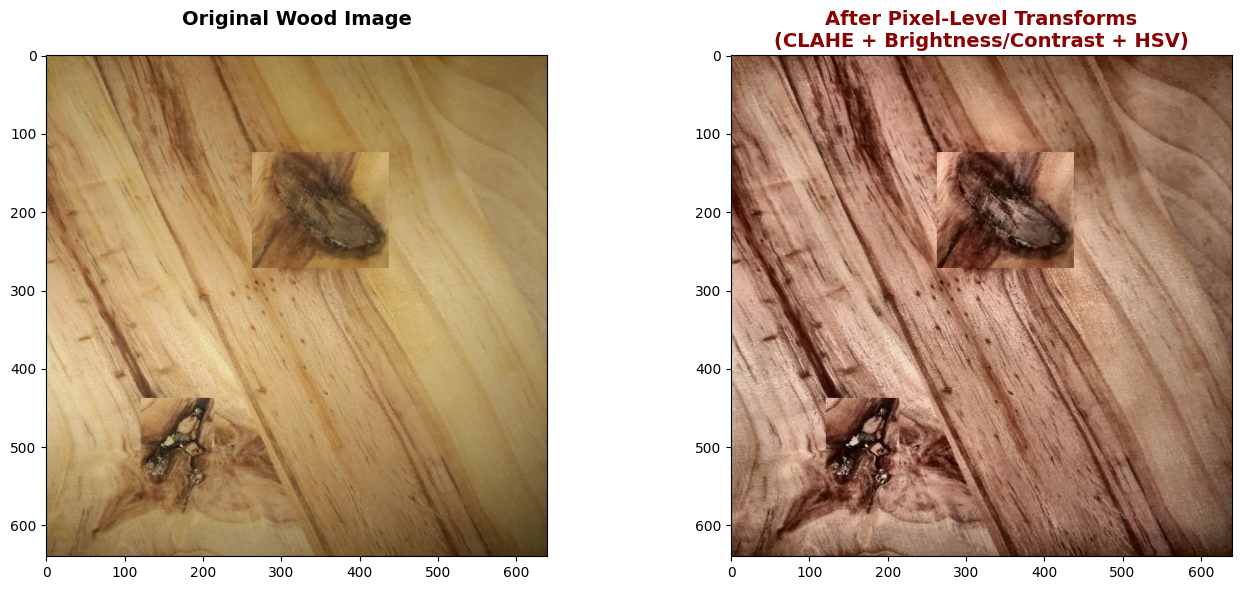

In [16]:
import cv2
import matplotlib.pyplot as plt
import albumentations as A
import os

# 1. Đường dẫn đến 1 tấm ảnh ván gỗ bất kỳ trong tập Train của bạn
# (Bạn hãy thay 'ten_anh_cua_ban.jpg' bằng tên file có thật nhé)
image_path = '/content/refined_dataset/train/images/0-1014-_jpg.rf.16fe23d01638902c8d41700f5973d9c9.jpg'

if not os.path.exists(image_path):
    print(f"⚠️ Không tìm thấy ảnh tại: {image_path}. Vui lòng sửa lại tên file!")
else:
    # 2. Đọc ảnh và chuyển từ BGR (chuẩn của OpenCV) sang RGB (chuẩn của Matplotlib)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 3. Định nghĩa LUỒNG BIẾN ĐỔI CHỈ Ở CẤP ĐỘ ĐIỂM ẢNH (Pixel-level)
    # Ở đây mình đặt xác suất p=1.0 để chắc chắn hiệu ứng sẽ xảy ra cho bạn xem thử
    pixel_transform = A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1.0),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=1.0)
    ])

    # 4. Áp dụng Augmentation
    augmented = pixel_transform(image=image)
    image_aug = augmented['image']

    # 5. Trực quan hóa (Vẽ 2 ảnh cạnh nhau)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Ảnh gốc bên trái
    axes[0].imshow(image)
    axes[0].set_title('Original Wood Image\n', fontsize=14, fontweight='bold')
    axes[0].axis('on') # Tắt trục tọa độ cho đẹp

    # Ảnh đã Augment bên phải
    axes[1].imshow(image_aug)
    axes[1].set_title('After Pixel-Level Transforms\n(CLAHE + Brightness/Contrast + HSV)', fontsize=14, fontweight='bold', color='darkred')
    axes[1].axis('on')

    # Căn chỉnh và hiển thị
    plt.tight_layout()
    plt.show()

    # (Tùy chọn) Lưu bức ảnh so sánh này ra file để chèn vào Word
    # fig.savefig('/content/pixel_level_demo.png', dpi=300, bbox_inches='tight')
    # print("Đã lưu file ảnh so sánh chất lượng cao: pixel_level_demo.png")

In [ ]:
import cv2
import matplotlib.pyplot as plt
import albumentations as A
import os

# 1. Cấu hình đường dẫn (Thay tên file thực tế của bạn vào đây)
image_path = '/content/refined_dataset/train/images/0-1040-_jpg.rf.19d278ed84422706a6be053968d04935.jpg'
label_path = '/content/refined_dataset/train/labels/wood_sample_01.txt'

def plot_bboxes(img, bboxes, color=(255, 0, 0), thickness=5):
    """Hàm vẽ Bounding Box lên ảnh để kiểm tra trực quan"""
    img_copy = img.copy()
    h, w = img_copy.shape[:2]
    for bbox in bboxes:
        cx, cy, bw, bh = bbox
        # Chuyển từ YOLO (0-1) sang Pixel tuyệt đối
        x1 = int((cx - bw/2) * w)
        y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w)
        y2 = int((cy + bh/2) * h)
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, thickness)
    return img_copy

if not os.path.exists(image_path) or not os.path.exists(label_path):
    print("⚠️ Cảnh báo: Vui lòng kiểm tra lại đường dẫn ảnh và nhãn!")
else:
    # 2. Đọc ảnh và nhãn gốc
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    bboxes = []
    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                # Format YOLO: [class_id, x_center, y_center, width, height]
                bboxes.append([float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])])

    # 3. Định nghĩa Pipeline biến đổi KHÔNG GIAN (Spatial-level)
    # Chúng ta dùng p=1.0 để demo rõ rệt các phép biến đổi
    spatial_transform = A.Compose([
        A.HorizontalFlip(p=1.0),
        A.RandomRotate90(p=1.0),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=1.0),
        A.RandomResizedCrop(height=1280, width=1280, scale=(0.5, 1.0), p=1.0)
    ], bbox_params=A.BboxParams(format='yolo', label_fields=[]))

    # 4. Áp dụng Augmentation (Tự động tính toán lại Bbox)
    transformed = spatial_transform(image=image, bboxes=bboxes)
    image_aug = transformed['image']
    bboxes_aug = transformed['bboxes']

    # 5. Vẽ Bounding Box lên cả 2 ảnh để so sánh độ chính xác
    img_with_boxes = plot_bboxes(image, bboxes)
    img_aug_with_boxes = plot_bboxes(image_aug, bboxes_aug)

    # 6. Trực quan hóa
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    axes[0].imshow(img_with_boxes)
    axes[0].set_title('Original Wood Surface\n(Tọa độ gốc)', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(img_aug_with_boxes)
    axes[1].set_title('After Spatial Transforms\n(Xoay, Lật, Cắt & Tự cập nhật Bbox)', fontsize=14, fontweight='bold', color='blue')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # Lưu kết quả demo
    # fig.savefig('/content/spatial_level_demo.png', dpi=300)